# PyIRI spherical harmonics
This tutorial is made of 3 parts:
- 1. Grid reconstruction using the `PyIRI.spherical_harmonics` library (`spharm`)
- 2. How the coefficients files provided were created
- 3. A detailed look into the SH and DFT functions used in `spharm`

# Part I: Grid reconstruction using `spharm`

Spherical Harmonics for GEO grid: 3.0036 seconds
Original PyIRI for GEO grid: 0.6175 seconds
Spherical Harmonics for MLT grid: 1.5954 seconds
Original PyIRI for MLT grid: 1.7172 seconds


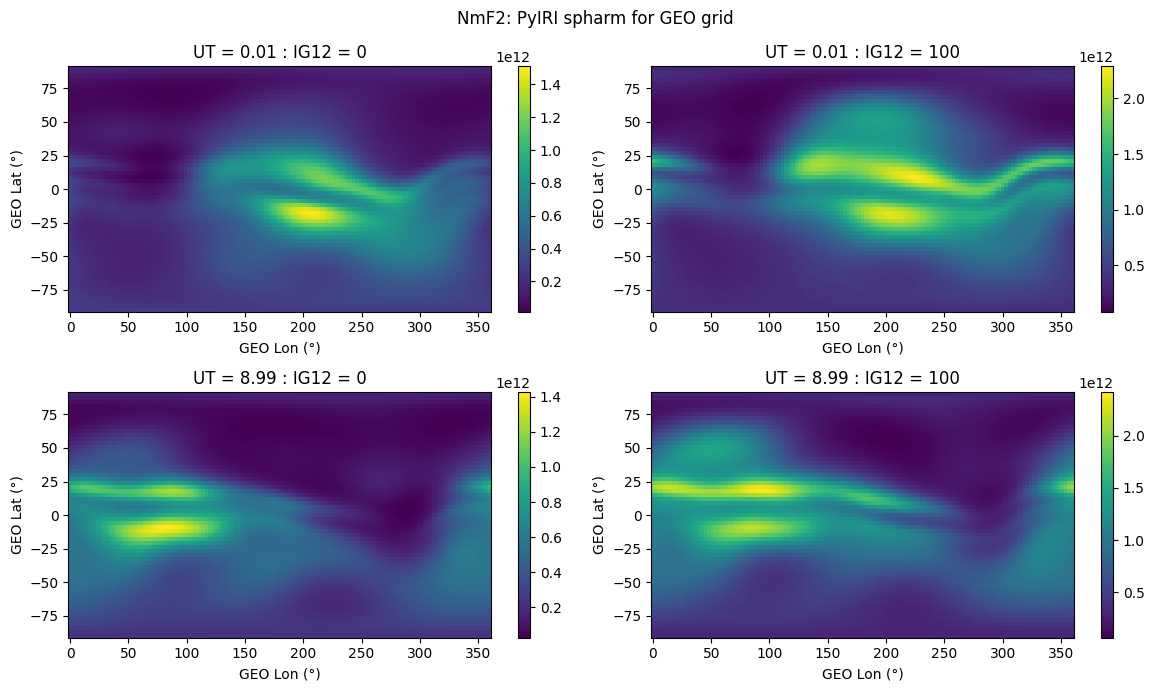

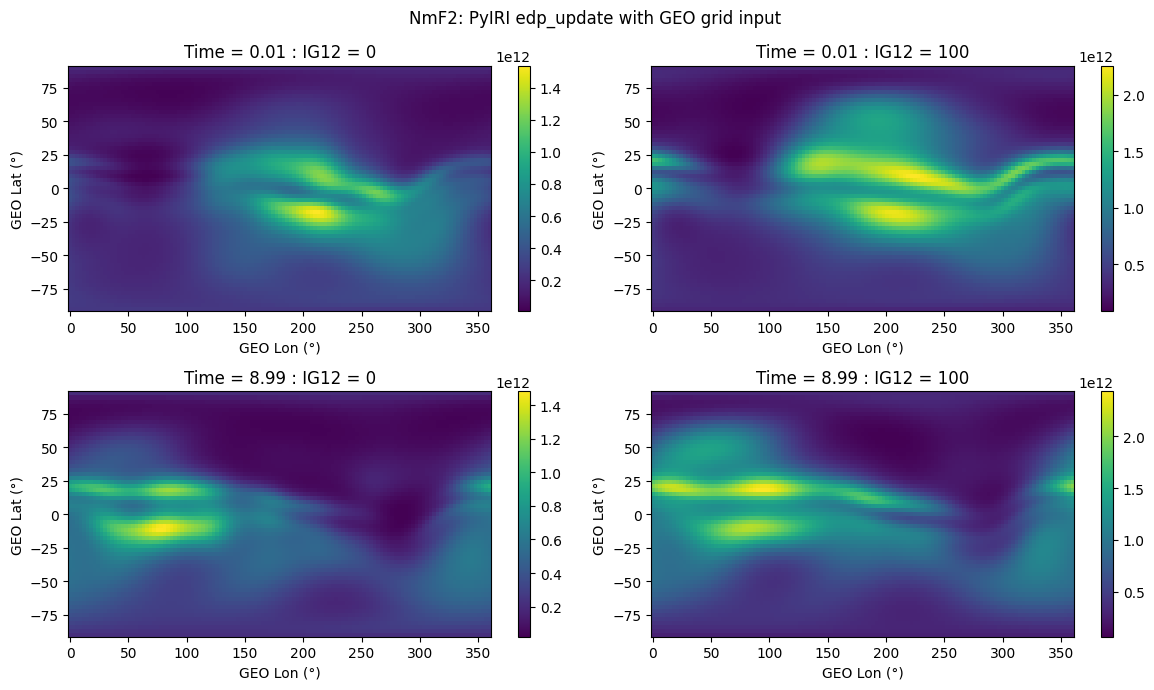

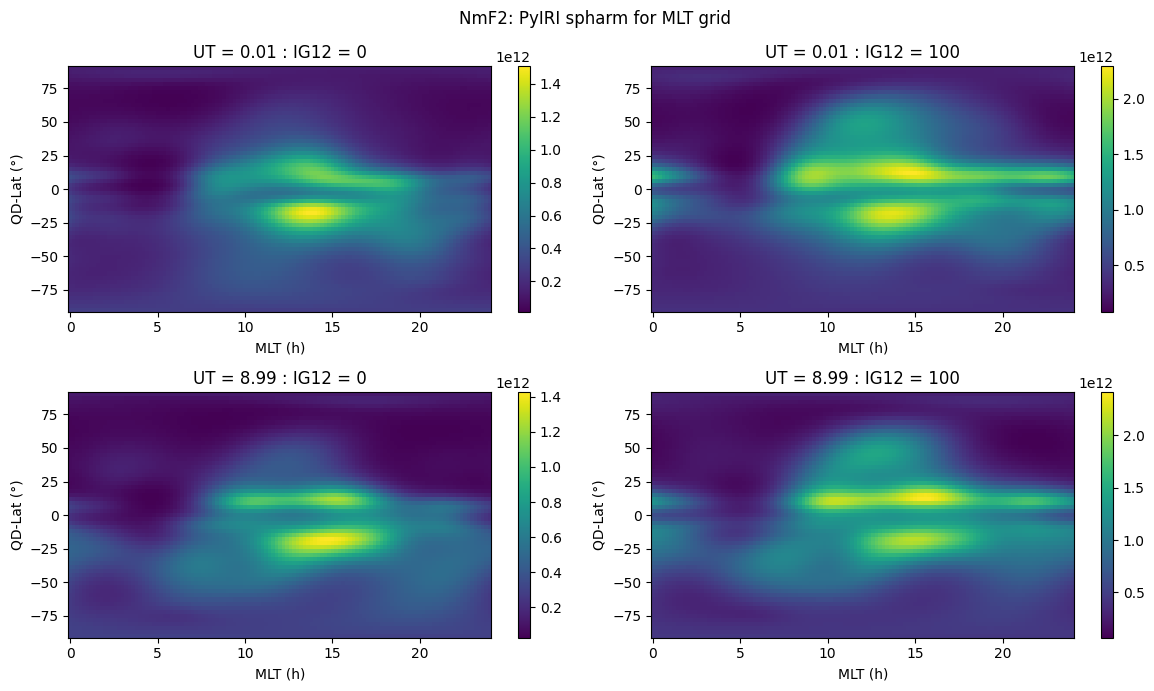

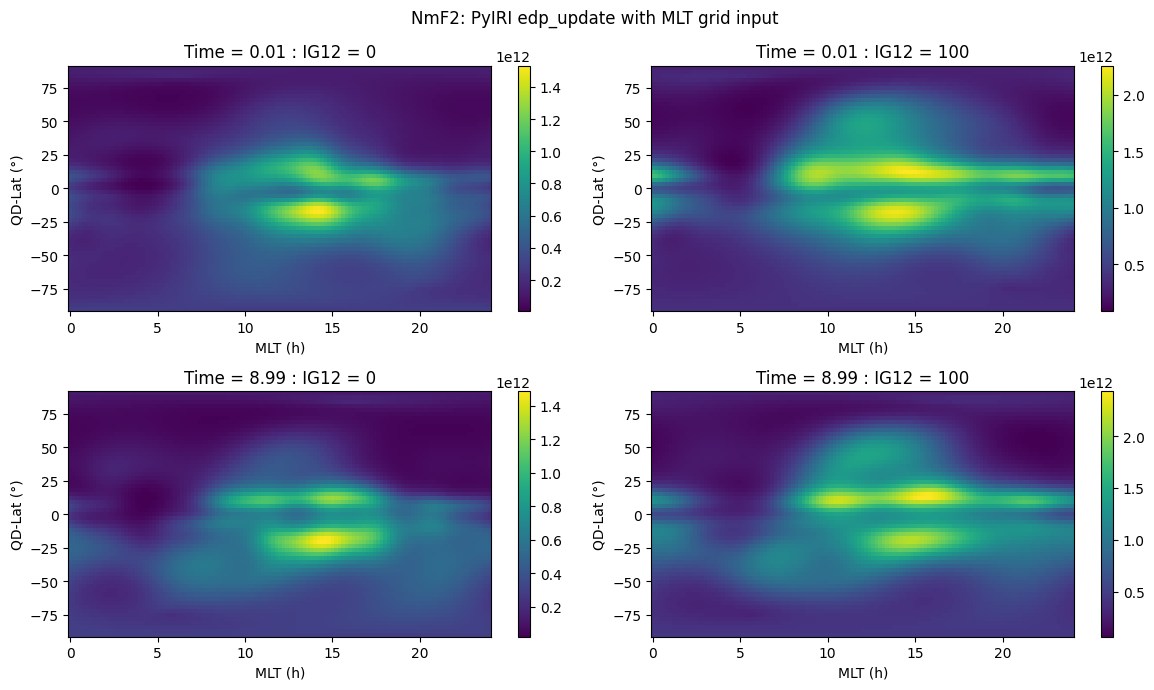

In [7]:
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import time
from apexpy import Apex

# Import original PyIRI
import PyIRI
import PyIRI.edp_update as ml

# Import SH PyIRI
import sys
sys.path.append('/home/nsrvs/')
import PyIRI_develop.PyIRI
import PyIRI_develop.PyIRI.spherical_harmonics as spharm
from importlib import reload
reload(spharm)

# Parameters
year = 2025
mth = 12
ddeg = 3
coeff_dir = PyIRI_develop.PyIRI.coeff_dir
# NOTE: PyIRI.coeff_dir still used inside IRI_monthly_mean_par() to calculate
# inc, modip, and mag lat

# Create grid of GEO or MLT coordinates
lon_range = np.arange(0, 360 + ddeg, ddeg)
lat_range = np.arange(-90, 90 + ddeg, ddeg)
aLat_2d, aLon_2d = np.meshgrid(lat_range, lon_range)
aLat_1d = aLat_2d.reshape(aLat_2d.size)
aLon_1d = aLon_2d.reshape(aLon_2d.size)

# Create array of UT
aUT = np.array([0.01, 8.99])

# Get NmF2 using spharm for GEO grid
start = time.time()
F2, *_ = spharm.IRI_monthly_mean_par(year, mth, aUT, aLon_1d, aLat_1d, 
                                     coeff_dir, coord='geo', foF2_coeff='CCIR')
end = time.time()
aParam = F2['Nm']

fig, ax = plt.subplots(2, 2, figsize = (12, 7))
fig.suptitle('NmF2: PyIRI spharm for GEO grid')
for iUT in range(2):
    axes = ax[iUT, :]
    for iIG in range(2):
        ax_plot = axes[iIG]
        ax_plot.set_xlabel('GEO Lon (°)')
        ax_plot.set_ylabel('GEO Lat (°)')
        aParam_2d = aParam[iUT, :, iIG].reshape(aLat_2d.shape)
        mesh = ax_plot.pcolormesh(aLon_2d, aLat_2d, aParam_2d)
        ax_plot.set_title(f'UT = {aUT[iUT]:03.2f} : IG12 = {[0, 100][iIG]}')
        plt.colorbar(mesh)
plt.tight_layout()
print(f"Spherical Harmonics for GEO grid: {end - start:.4f} seconds")

# Compare with original PyIRI (edp_update) for GEO grid
start = time.time()
F2, *_ = ml.IRI_monthly_mean_par(year, mth, aUT, aLon_1d, aLat_1d,
                                 PyIRI.coeff_dir)
end = time.time()
aTruth = F2['Nm']

fig, ax = plt.subplots(2, 2, figsize = (12, 7))
fig.suptitle('NmF2: PyIRI edp_update with GEO grid input')
for iUT in range(2):
    axes = ax[iUT, :]
    for iIG in range(2):
        ax_plot = axes[iIG]
        ax_plot.set_xlabel('GEO Lon (°)')
        ax_plot.set_ylabel('GEO Lat (°)')
        aTruth_2d = aTruth[iUT, :, iIG].reshape(aLat_2d.shape)
        mesh = ax_plot.pcolormesh(aLon_2d, aLat_2d, aTruth_2d)
        ax_plot.set_title(f'Time = {aUT[iUT]:03.2f} : IG12 = {[0, 100][iIG]}')
        plt.colorbar(mesh)
plt.tight_layout()
print(f"Original PyIRI for GEO grid: {end - start:.4f} seconds")

# Get NmF2 using spharm for MLT grid
start = time.time()
F2, *_ = spharm.IRI_monthly_mean_par(year, mth, aUT, aLon_1d / 15, aLat_1d, 
                                     coeff_dir, coord='mlt', foF2_coeff='CCIR')
end = time.time()
aParam = F2['Nm']

fig, ax = plt.subplots(2, 2, figsize = (12, 7))
fig.suptitle('NmF2: PyIRI spharm for MLT grid')
for iUT in range(2):
    axes = ax[iUT, :]
    for iIG in range(2):
        ax_plot = axes[iIG]
        ax_plot.set_xlabel('MLT (h)')
        ax_plot.set_ylabel('QD-Lat (°)')
        aParam_2d = aParam[iUT, :, iIG].reshape(aLat_2d.shape)
        mesh = ax_plot.pcolormesh(aLon_2d / 15, aLat_2d, aParam_2d)
        ax_plot.set_title(f'UT = {aUT[iUT]:03.2f} : IG12 = {[0, 100][iIG]}')
        plt.colorbar(mesh)
plt.tight_layout()
print(f"Spherical Harmonics for MLT grid: {end - start:.4f} seconds")

# Compare with original PyIRI (edp_update) for MLT grid
start = time.time()
aTruth = np.zeros((len(aUT), aLat_1d.size, 2))
apdtime = pd.to_datetime(dt.datetime(year, mth, 15)) \
                                        + pd.to_timedelta(aUT, 'hours')
for iUT in range(len(aUT)):
    pdtime = apdtime[iUT]
    A = Apex(pdtime)
    aGlat_from_MLT, aGlon_from_MLT = A.convert(aLat_1d, aLon_1d / 15,
                                'mlt', 'geo', height=0.,
                                        datetime=pdtime)
    F2, *_ = ml.IRI_monthly_mean_par(year, mth, np.array([aUT[iUT]]),
                                     aGlon_from_MLT, aGlat_from_MLT,
                                     PyIRI.coeff_dir)
    aTruth[iUT, :, :] = F2['Nm']
end = time.time()

fig, ax = plt.subplots(2, 2, figsize = (12, 7))
fig.suptitle('NmF2: PyIRI edp_update with MLT grid input')
for iUT in range(2):
    axes = ax[iUT, :]
    for iIG in range(2):
        ax_plot = axes[iIG]
        ax_plot.set_xlabel('MLT (h)')
        ax_plot.set_ylabel('QD-Lat (°)')
        aTruth_2d = aTruth[iUT, :, iIG].reshape(aLat_2d.shape)
        mesh = ax_plot.pcolormesh(aLon_2d / 15, aLat_2d, aTruth_2d)
        ax_plot.set_title(f'Time = {aUT[iUT]:03.2f} : IG12 = {[0, 100][iIG]}')
        plt.colorbar(mesh)
plt.tight_layout()
print(f"Original PyIRI for MLT grid: {end - start:.4f} seconds")

# Part II and III
...TBD